#The Evolution of EV over the period 2010 to 2025 - Data from International Energy Agency https://www.iea.org/data-and-statistics/data-product/global-ev-outlook-2026#global-ev-data

Import

In [303]:
# importing
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

Load data

In [304]:
# Load the Data, Read CSv File and see the first few values to know about the data, and decimal=',' convert data ( str) to decimal values
df = pd.read_csv('/content/GEVO_EV_2026-Table 1.csv', sep=';',decimal=',')
df.head(5)

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group,Unnamed: 9
0,Chile,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,1.0,Other,NaN
1,Norway,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,18.0,Other,NaN
2,Portugal,Historical,EV charging points,EVSE,Publicly available fast,2011,charging points,6.0,Other,NaN
3,Canada,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,2.0,Other,NaN
4,Chile,Historical,EV charging points,EVSE,Publicly available fast,2012,charging points,4.0,Other,NaN


List Columns

# Data Exploration (Exploratory Data Analysis - EDA)

In [305]:
df.columns

Index(['region_country', 'category', 'parameter', 'mode', 'powertrain', 'year',
       'unit', 'value', 'Aggregate group', 'Unnamed: 9'],
      dtype='object')

Drop Columns

In [306]:
# python automatically created a coloumn after aggregare group as the delimiter is ; ( drop the two coloumns)
df = df.drop(columns =['Aggregate group', 'Unnamed: 9'])


Describe Dataset

In [307]:
# Get the information such as Count, Mean, Min, Max etc.. unit column contains multiple measurement types: Vehicles charging points GWh percent kW/EV Million barrels/day etc.
df.describe(include='all')


,region_country,category,parameter,mode,powertrain,year,unit,value
count,48098,49176,49176,49176,49176,49176.000000,26594,4.917600e+04
unique,72,3,19,13,10,NaN,9,NaN
top,China,Historical,EV stock,Cars,EV,NaN,Vehicles,NaN
freq,2841,47915,7816,7872,15305,NaN,15397,NaN
mean,NaN,NaN,NaN,NaN,NaN,2018.911217,NaN,3.216098e+05
std,NaN,NaN,NaN,NaN,NaN,4.960293,NaN,5.558912e+06
min,NaN,NaN,NaN,NaN,NaN,2010.000000,NaN,1.000000e-06
25%,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,6.200000e+01
50%,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,1.700000e+04
75%,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,6.200000e+04


Lowercase string

In [308]:
df['unit'] = df['unit'].str.lower() # make the unit values to lowercase

Get Unique values

In [309]:
df['category'].unique() # Get Unique values in category
df['mode'].unique() # Get unique values in Mode
df[['region_country','category','parameter','mode','powertrain','year','unit']].apply(lambda x: x.unique()).tolist() # Check the unique values in coloumns region_country,category,parameter,mode,powertrain,year,unit and get a list

[array(['Chile', 'Norway', 'Portugal', 'Canada', 'France', 'Germany',
        'Italy', 'Netherlands', 'Switzerland', 'Belgium', 'Denmark',
        'Finland', 'Spain', 'United Kingdom', 'Greece', 'Iceland',
        'Poland', 'Sweden', 'Australia', 'Mexico', 'New Zealand',
        'South Africa', 'Thailand', 'Brazil', 'Malaysia', 'Austria',
        'Turkiye', 'Colombia', 'Indonesia', 'Israel', 'Jordan', 'Russia',
        'Viet Nam', 'Costa Rica', 'Philippines', 'Singapore',
        'United Arab Emirates', 'Cambodia', 'Lao PDR', 'Uzbekistan',
        'World', 'China', 'Europe', 'India', 'Latin America', 'Japan',
        'Korea', 'Southeast Asia', 'USA', 'Advanced Economies',
        'Developing Economies excl. China', 'Africa', 'Asia Pacific',
        'European Union', 'Middle East and Caspian', 'Bulgaria', 'Croatia',
        'Cyprus', 'Czech Republic', 'Estonia', 'Hungary', 'Ireland',
        'Latvia', 'Lithuania', 'Luxembourg', 'Nepal', 'Romania',
        'Seychelles', 'Slovakia', 'Slov

Get info

In [310]:
df.info() # Get the information about coloumn names null values and types of values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49176 entries, 0 to 49175
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   region_country  48098 non-null  object 
 1   category        49176 non-null  object 
 2   parameter       49176 non-null  object 
 3   mode            49176 non-null  object 
 4   powertrain      49176 non-null  object 
 5   year            49176 non-null  int64  
 6   unit            26594 non-null  object 
 7   value           49176 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 3.0+ MB


Check null values

In [311]:
# Checking null values
df.isnull().sum()

,0
region_country,1078
category,0
parameter,0
mode,0
powertrain,0
year,0
unit,22582
value,0


Fill null values

In [312]:
# filling the null values of unit with usd_2025
missing_unit = df[df['unit'].isnull()] # Filter the data where unit is null and get the datafarame
df['unit'] = df['unit'].fillna('USD_2025')
df.isnull().sum() # get the sum of all null values in each coloumn



,0
region_country,1078
category,0
parameter,0
mode,0
powertrain,0
year,0
unit,0
value,0


## Remove na

In [313]:
world_df = df.copy() # took a copy of the dataframe for world analysys
df = df.dropna(subset='region_country')# dropping the coloumn region_country which have null values, because without knowing the country or region we are unable to do geographic analysis
df.isnull().sum() # get the sum of all null values in each coloumn

,0
region_country,0
category,0
parameter,0
mode,0
powertrain,0
year,0
unit,0
value,0


Replace country names for better understanding

In [314]:
df['region_country'] = df['region_country'].replace({'Turkiye': 'Turkey','Viet Nam': 'Vietnam','Lao PDR': 'Laos'})

Get years covered

In [315]:
# Years covered
minimum_year = df['year'].min() # Get minium year from year coloumn
maximum_year = df['year'].max() # Get minium year from year coloumn
years_covered = f"{minimum_year} - {maximum_year}"
print(years_covered) # Get years covered in the dataset


2010 - 2035


# 1. HOW THE ELECTRIC VEHICLE GROWN FROM YEAR 2010 TO 2025

Understand the speed of Ev growth






In [316]:
# To get how many total vehicles are there in road for the year from 2010 to 2025
df['mode'].unique() # get unique values from the coloumn mode
df['powertrain'].unique() # get unique values from the coloumn powertrain
mode_graph = ['2 and 3 wheelers', 'Buses', 'Cars', 'Trucks', 'Vans'] # create a list with types of vehicle
df_total_vehicle_by_year= df[(df['region_country'] == 'World') & (df['parameter'] == 'EV stock') & (df['category'] == 'Historical') & (df['powertrain'] == 'EV') & (df['mode'].isin(mode_graph))].groupby('year')['value'].sum()/1000000 # convert vehicle count to millions
#df_total_vehicle_by_year


# Chart 1- Total global Ev vehicles on road (2010-2025)
Plot the line chart to analyse the Ev growth over the years, EV adoption accelerates strongly after 2020, with projections showing continued steep growth toward 2025,This shows the total number of electric vehicles on the road worldwide each year. nearly flat until 2016, then explosive

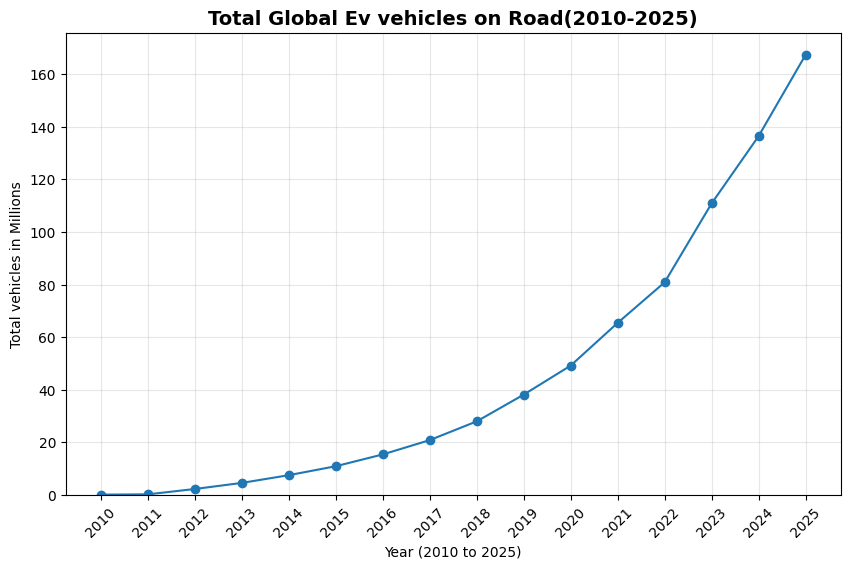

In [317]:
plt.figure(figsize=(10, 6)) # graph size 10*6
my_light_colors = ["#0D9488", "#14B8A6", "#5EEAD4", "#38BDF8", "#0EA5E9", "#6366F1", "#8B5CF6", "#06B6D4", "#10B981", "#3B82F6"] #["#0077BB", "#EE7733", "#009988", "#CC3311", "#33BBEE", "#EE3377", "#BBBBBB", "#000000", "#44BB99", "#AAAA00"]
plt.plot(df_total_vehicle_by_year.index, df_total_vehicle_by_year.values, marker = 'o') # plot the graph with the index and values ( year and count of vehicles) . marker is for real data points and s is the shape

plt.title('Total Global Ev vehicles on Road(2010-2025)',fontsize=14, fontweight='bold') # The title
plt.xlabel('Year (2010 to 2025)') # The x label
plt.ylabel('Total vehicles in Millions') # The y label
plt.ylim(bottom=0)
plt.xticks(df_total_vehicle_by_year.index, rotation=45) # tilt the title by 45 degree
plt.grid(alpha=0.3)
plt.show()

# 2. TOP 10 Countries leads in EV market in 2025

In [318]:

df['region_country'].unique() # get unique values in country
not_countries = ['World', 'Europe', 'European Union', 'Asia Pacific', 'Southeast Asia','Latin America', 'Africa', 'Middle East and Caspian','Advanced Economies', 'Developing Economies excl. China'] # get the not countries from the contries list
countries_only = df[~df['region_country'].isin(not_countries)] # get the list of countries
top_10_countries_Ev_sales = (countries_only[(countries_only['year'] == 2025) &(countries_only['parameter']  == 'EV sales') & (countries_only['category']   == 'Historical') & (countries_only['powertrain'] == 'EV')].groupby('region_country')['value'].sum().sort_values(ascending=False).head(10)) # get the list of first 10 countries by Ev
top_10_countries_Ev_sales_in_m = top_10_countries_Ev_sales / 1000000 # convert to millions
top_10_countries_Ev_sales_in_m

,value
region_country,
China,20.98000
India,2.28350
USA,1.51590
Vietnam,0.92011
Germany,0.90620
United Kingdom,0.74650
France,0.50361
Turkey,0.41000
Netherlands,0.26019


# Chart 2- Total EV sales (all vehicle types combined) in 2025 for the 10 leading countries.


Growth is uneven across countries, a small number of countries account for a large share of total EV sales.EV sales distribution is right skewed, meaning a few countries dominate adoption, a tiny number of countries dominate the market. China alone sells more EVs than the other 9 combined

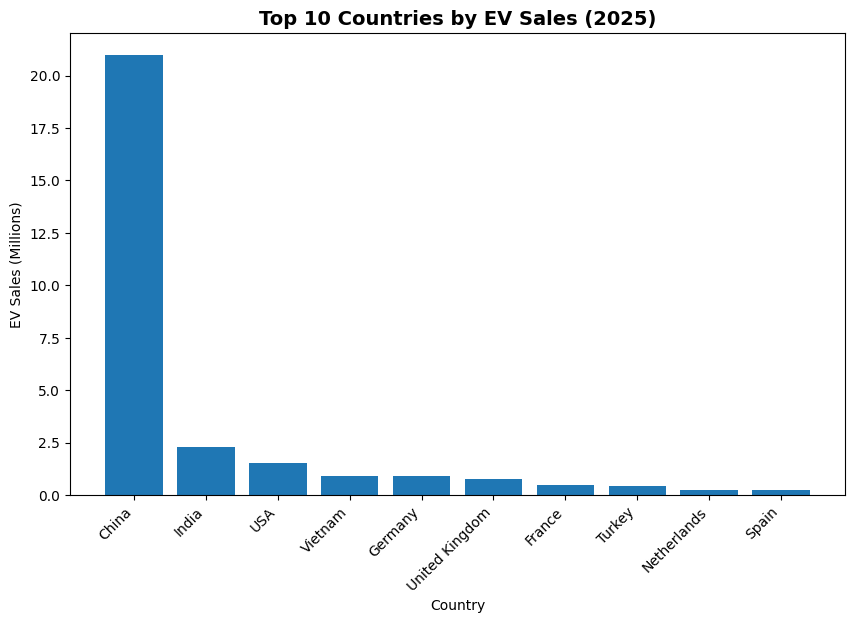

In [319]:
plt.figure(figsize=(10, 6))
plt.bar(top_10_countries_Ev_sales_in_m.index, top_10_countries_Ev_sales_in_m.values)

plt.title('Top 10 Countries by EV Sales (2025)',fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('EV Sales (Millions)')

plt.xticks(rotation=45, ha='right')
plt.show()

# 3. BEV vs PHEV , Battery Electric Vehicle, Plug-in Hybrid Electric Vehicle

In [320]:
df['parameter'].unique()
bev_phev = (df[ (df['region_country'] == 'World') & (df['parameter'] == 'EV sales') &(df['category']  == 'Historical') & (df['powertrain'].isin(['BEV', 'PHEV', ]))].groupby(['year', 'powertrain'])['value'].sum().unstack())/1000000 # filter and unstack( transform checklist data to a table format)
bev_phev



powertrain,BEV,PHEV
year,,
2010,0.050237,0.000450
2011,0.074890,0.009160
2012,2.071628,0.060521
2013,2.423240,0.092805
2014,3.015355,0.136020
2015,3.204000,0.204793
2016,3.709000,0.318073
2017,4.540000,0.440434
2018,6.650000,0.651494


Chart showing growth of BE. PHEV over the years, Two types of electric vehicles compete: BEV (fully battery, no petrol) and PHEV (has both a battery and a petrol engine). BEV is growing faster and pulling ahead

> Good for charging infrastructure planning



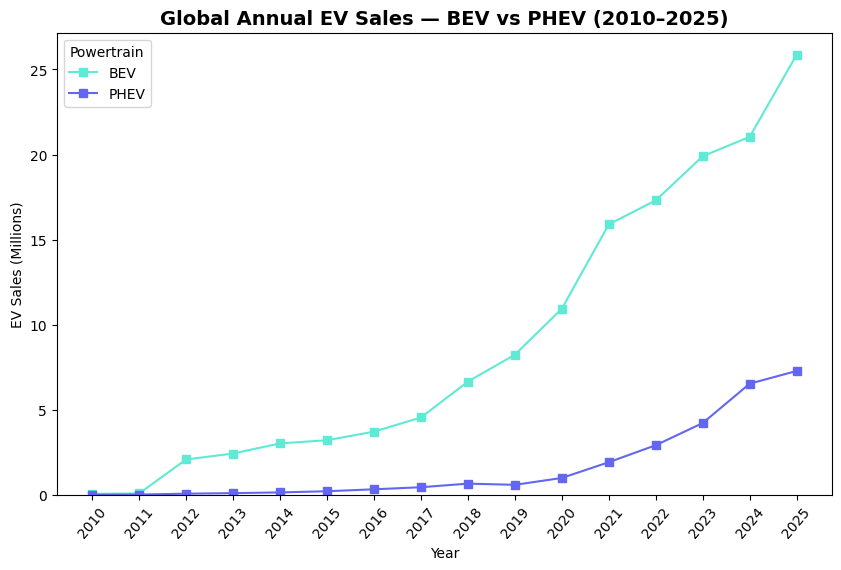

In [321]:
plt.figure(figsize=(10, 6))
plt.plot(bev_phev.index, bev_phev['BEV'],  marker='s', label='BEV',  color=my_light_colors[2])
plt.plot(bev_phev.index, bev_phev['PHEV'], marker='s', label='PHEV', color=my_light_colors[5])

plt.title('Global Annual EV Sales — BEV vs PHEV (2010–2025)',fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('EV Sales (Millions)')
plt.xticks(bev_phev.index, rotation=50)
plt.legend(title='Powertrain')
plt.ylim(bottom=0)
plt.show()

4 EV Market Share across major regions

In [322]:
regions = ['Europe', 'Latin America', 'Southeast Asia', 'Africa','Asia Pacific', 'Middle East and Caspian']
df_ev_share = df[(df['region_country']).isin(regions) & (df['parameter'] == 'EV sales') & (df['category'] == 'Historical') & (df['powertrain'] == 'EV')].groupby(['year', 'region_country'])['value'].sum().unstack()/1000000 #total electric vehicle sales across regions
#df_ev

# Chart 4 - Total global Ev sales in regions

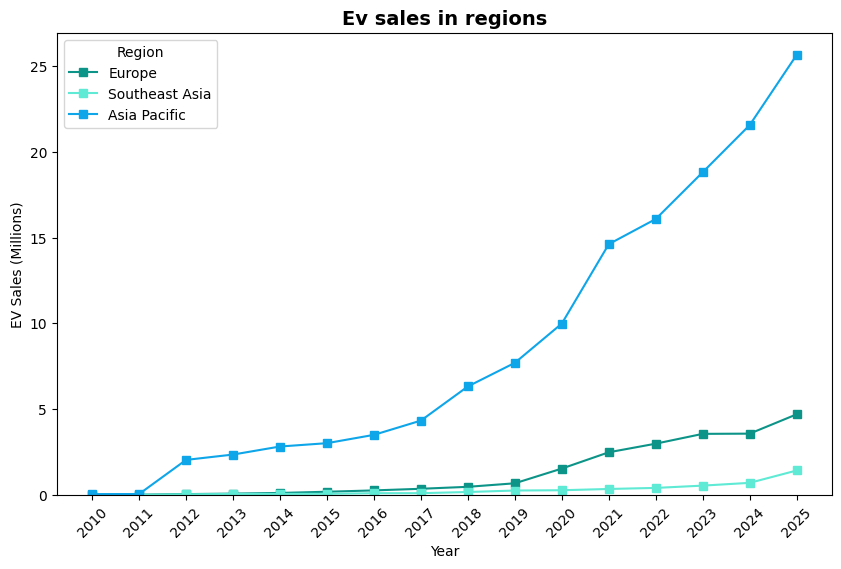

In [323]:
plt.figure(figsize=(10, 6))
plt.plot(df_ev_share.index, df_ev_share['Europe'],  marker='s', label='Europe',  color=my_light_colors[0])
#plt.plot(df_ev_share.index, df_ev_share['Latin America'], marker='s', label='Latin America', color=my_light_colors[1])
plt.plot(df_ev_share.index, df_ev_share['Southeast Asia'],  marker='s', label='Southeast Asia',  color=my_light_colors[2])
#plt.plot(df_ev_share.index, df_ev_share['Africa'], marker='s', label='Africa', color=my_light_colors[3])
plt.plot(df_ev_share.index, df_ev_share['Asia Pacific'], marker='s', label='Asia Pacific', color=my_light_colors[4])
#plt.plot(df_ev_share.index, df_ev_share['Middle East and Caspian'], marker='s', label='Middle East and Caspian', color=my_light_colors[5])


plt.title('Ev sales in regions',fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('EV Sales (Millions)')
plt.xticks(df_ev_share.index, rotation=45)
plt.legend(title='Region')
plt.ylim(bottom=0)
plt.show()

In [324]:
df_total_vehicle_by_mode= df[(df['region_country'] == 'World') & (df['year'] == 2025) & (df['parameter'] == 'EV stock') & (df['category'] == 'Historical') & (df['powertrain'] == 'EV') & (df['mode'].isin(mode_graph))].groupby('mode')['value'].sum()/1000000
df_total_vehicle_by_mode

,value
mode,
2 and 3 wheelers,89.00
Buses,0.81
Cars,75.00
Trucks,1.10
Vans,1.50


# Chart 5- cahrging growth vs Ev stock

Charging infrastructure and EV stock appear positively related, suggesting infrastructure expansion accompanies adoption growth. Each dot is a country. Countries with more EVs also have more public charging points. The log scale stretches the axis so tiny and huge countries can be compared. The positive relationship confirms: infrastructure follows adoption.

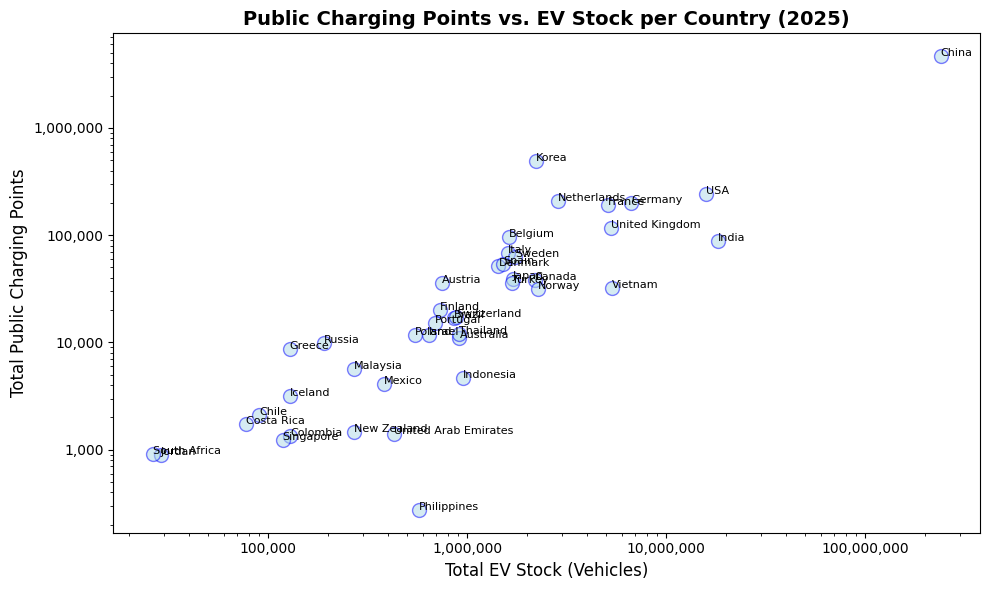

In [325]:
# stock vs charging points in country
get_countries_2025 = df[(df['year'] == 2025) & (~df['region_country'].isin(not_countries))]
stock_2025 = get_countries_2025[get_countries_2025['parameter'] == 'EV stock'].groupby('region_country')['value'].sum()
charge_2025 = get_countries_2025[get_countries_2025['parameter'] == 'EV charging points'].groupby('region_country')['value'].sum()
common_countries = stock_2025.index.intersection(charge_2025.index)

plt.figure(figsize=(10, 6))
plt.scatter(stock_2025[common_countries],charge_2025[common_countries],color="lightblue",edgecolor="b",s=100,alpha=0.5,)
for country in common_countries:
    plt.annotate(country, (stock_2025[country], charge_2025[country]), fontsize=8)

plt.title("Public Charging Points vs. EV Stock per Country (2025)",fontsize=14,fontweight="bold")
plt.xlabel("Total EV Stock (Vehicles)", fontsize=12)
plt.ylabel("Total Public Charging Points", fontsize=12)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

plt.tight_layout()
plt.show()

Two policy scenarios from the IEA. The green STEPS line (governments do what they've promised) reaches 315M EVs by 2035. The red CPS line (only current policies, no new ambition) reaches only 185M. The gray gap between them = the cost of political inaction.

# Chart 6- STEP and CPS compariason

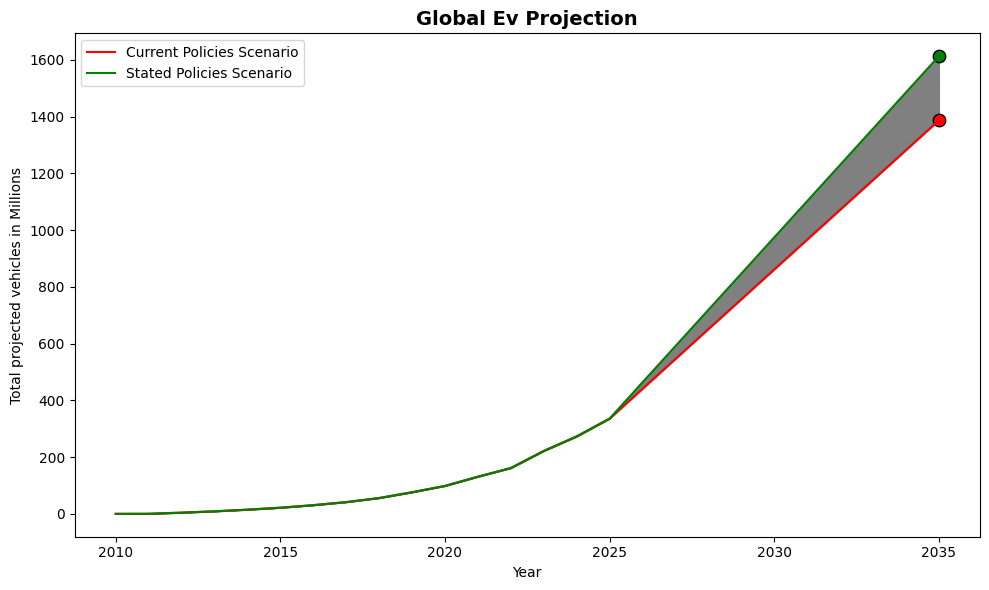

In [326]:
proj_data = df[(df["parameter"] == "EV stock") & (df["region_country"] == "World")] # Data for world ev stock

historical_track = (proj_data[proj_data["category"] == "Historical"]).groupby("year")["value"].sum()/1000000 # get the historical data by year for Ev stock
cps_2035 = (proj_data[proj_data["category"] == "Projection-CPS"].groupby("year")["value"].sum())/1000000 # get 2035 projection cps total ev stock
steps_2035 = (proj_data[proj_data["category"] == "Projection-STEPS"].groupby("year")["value"].sum())/1000000# get 2035 projection steps total ev stock

cps_track = pd.concat([historical_track, cps_2035]) #connect historical to cps 2035
steps_track = pd.concat([historical_track, steps_2035])#connect historical to steps 2035

plt.figure(figsize=(10, 6)) # desfine chart size

plt.plot(cps_track.index,cps_track.values,color='red',label='Current Policies Scenario')
plt.plot(steps_track.index,steps_track.values,color='green',label='Stated Policies Scenario')


plt.fill_between(cps_track.index,cps_track.values,steps_track.values,color='gray')

# Add markers s
plt.scatter([2035],[cps_2035.values[0]],color="red",edgecolor="black",s=80)
plt.scatter([2035],[steps_2035.values[0]],color="green",edgecolor="black",s=80)

# Formatting
plt.title('Global Ev Projection',fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total projected vehicles in Millions')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Cars dominate EV sales in every country (80%+), but India stands out with more 2/3-wheelers (motorbikes, rickshaws).

# Chart 7- Vehicle type composition in countries

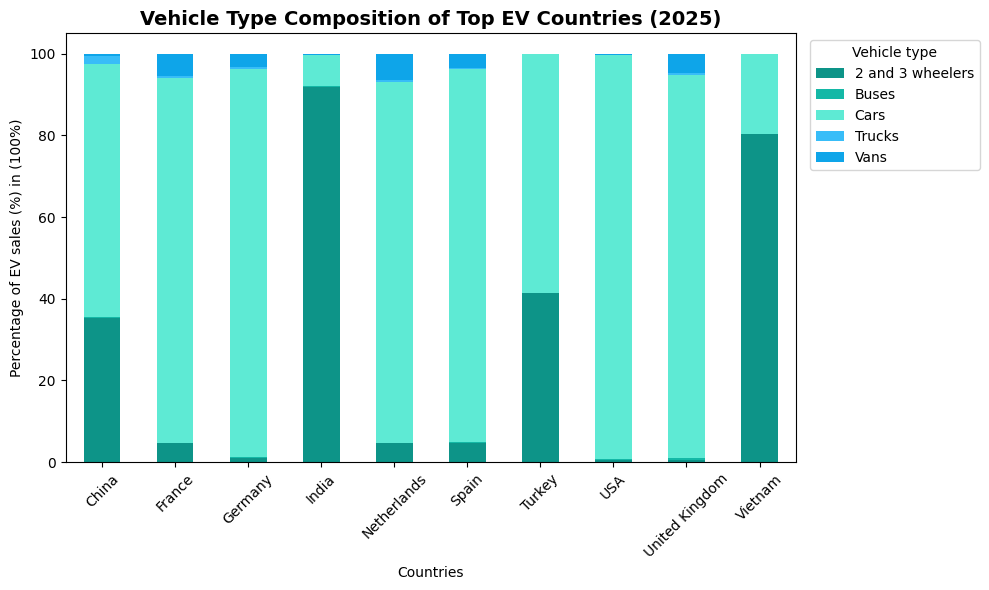

In [327]:


top_country_names = top_10_countries_Ev_sales.index # Get top 10 country names

vehicle_mix = df[(df["region_country"].isin(top_country_names))& (df["year"] == 2025)& (df["parameter"] == "EV sales")& (df["powertrain"] == "EV")] #filter the data

vehicle_mix = (vehicle_mix.groupby(["region_country", "mode"])["value"] .sum().unstack().fillna(0)) # create country and vehicle mode table


vehicle_mix_percent = vehicle_mix.div(vehicle_mix.sum(axis=1), axis=0) * 100 # Convert rows to percentages 100% total per country

vehicle_mix_percent.plot(kind="bar", stacked=True, figsize=(10,6),color = my_light_colors) # Plot graph

plt.title("Vehicle Type Composition of Top EV Countries (2025)", fontsize=14, fontweight='bold') # Give title
plt.xlabel("Countries") # give x label
plt.ylabel("Percentage of EV sales (%) in (100%)") # give y label

plt.legend(title="Vehicle type", bbox_to_anchor=(1.01, 1), loc="upper left") # give legend

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 8- Ev stock growth in 2025 vs projected growth in 2035(step method)

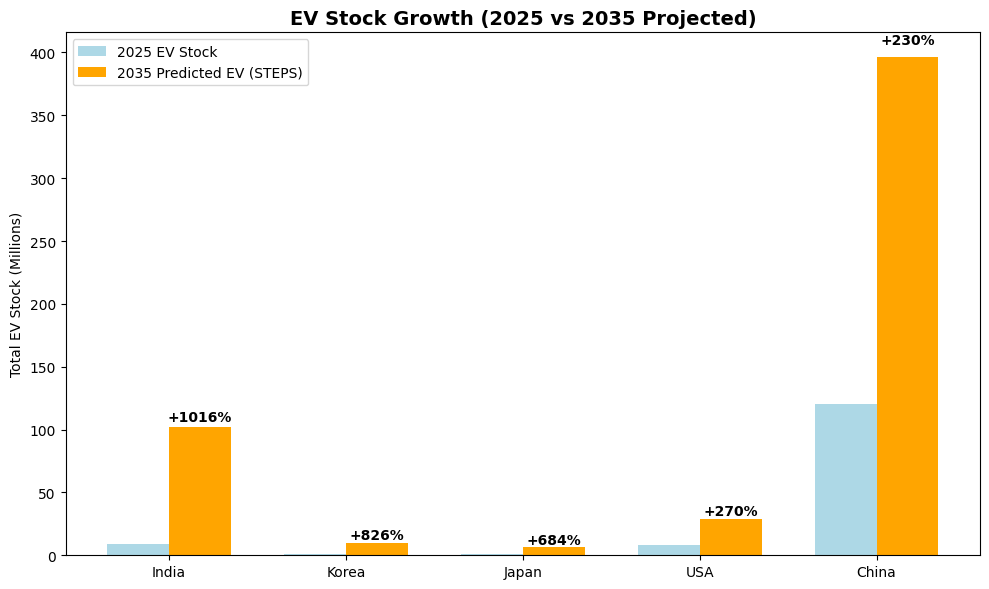

                increase_%
region_country            
India              1015.76
Korea               826.47
Japan               683.76
USA                 270.12
China               230.00


In [334]:

top_country_names = ["China", "USA", "India", "Japan", "Korea"]

f_stock = df[(df["parameter"] == "EV stock") & (df["powertrain"] == "EV") & (df["region_country"].isin(top_country_names))] #Filter

df_2025 = f_stock[(f_stock["year"] == 2025) & (f_stock["category"] == "Historical")] # Separate into 2025 and 2035 dataframes
df_2035 = f_stock[(f_stock["year"] == 2035) & (f_stock["category"] == "Projection-STEPS")]

ev_2025 = df_2025.groupby("region_country")["value"].sum() / 1_000_000 #  Sum up the values per country and convert to millions
ev_2035 = df_2035.groupby("region_country")["value"].sum() / 1_000_000

projection = pd.DataFrame({"EV_2025": ev_2025, "EV_2035": ev_2035}).fillna(0) # Combine into a clean summary table

projection["increase_%"] = ((projection["EV_2035"] - projection["EV_2025"]) / projection["EV_2025"]) * 100 # Calculate percentage increase and sort the table
projection = projection.sort_values(by="increase_%", ascending=False)


plt.figure(figsize=(10, 6)) # plot

x = np.arange(len(projection.index))
width = 0.35


plt.bar(x - width / 2, projection["EV_2025"], width, label="2025 EV Stock", color="lightblue") # Draw the side-by-side bars
plt.bar(x + width / 2, projection["EV_2035"], width, label="2035 Predicted EV (STEPS)", color="orange")

# Add growth percentage labels above the 2035 bars
for i in range(len(projection.index)):
    growth = projection["increase_%"].iloc[i]
    y_pos = projection["EV_2035"].iloc[i]
    x_pos = x[i] + width / 2  # Center text over the 2035 bar

    plt.text(x=x_pos,y=y_pos + (y_pos * 0.02), s=f"{growth:+.0f}%",ha="center",va="bottom",fontsize=10,fontweight="bold",)

# Formatting chart
plt.xticks(x, projection.index)
plt.ylabel("Total EV Stock (Millions)")
plt.title("EV Stock Growth (2025 vs 2035 Projected)", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Print growth table
print(projection[["increase_%"]].round(2))


In [329]:
total_ev_2025 = (df[(df['region_country'] == 'World') &(df['year'] == 2025) &(df['parameter'] == 'EV stock') &(df['category'] == 'Historical') &(df['powertrain'] == 'EV')]['value'].sum())/1000000
total_ev_2025

np.float64(167.41)

In [330]:
total_ev_car_2025 = (df[(df['region_country'] == 'World') &(df['year'] == 2025) &(df['parameter'] == 'EV stock') & (df['mode'] == 'Cars') &(df['category'] == 'Historical') &(df['powertrain'] == 'EV')]['value'].sum())/1000000
total_ev_car_2025


np.float64(75.0)

# Chart 9- Total car sale in market vs Ev car sale

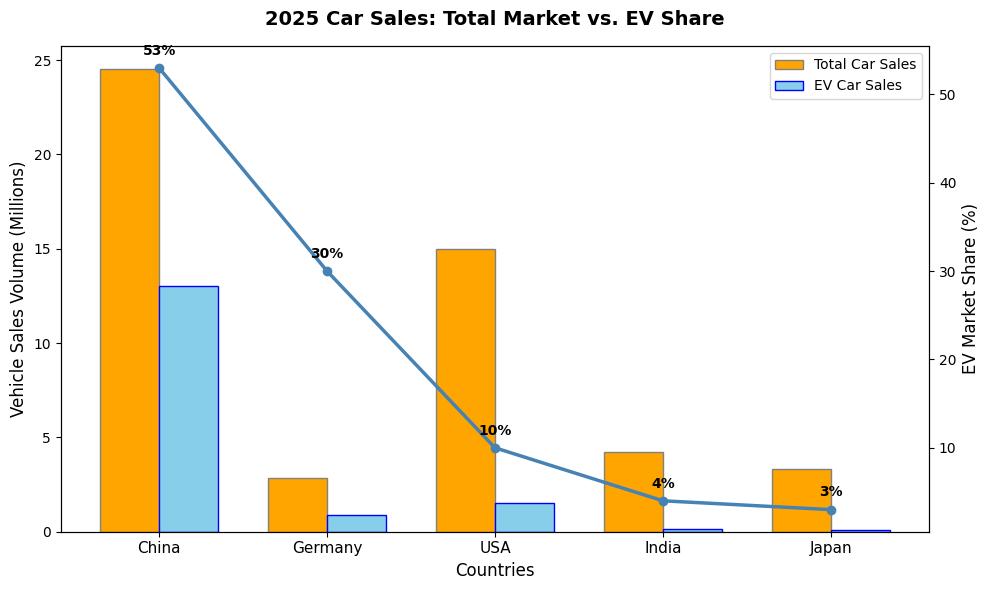

                Total Sales (M)  EV Sales (M)  EV Sales Share (%)
region_country                                                   
China                     24.53         13.00                53.0
Germany                    2.87          0.86                30.0
USA                       15.00          1.50                10.0
India                      4.25          0.17                 4.0
Japan                      3.33          0.10                 3.0


In [336]:
target_countries = ["China", "Germany", "USA", "India", "Japan"]
df_cars = df[
    (df["region_country"].isin(target_countries))
    & (df["year"] == 2025)
    & (df["mode"] == "Cars")
    & (df["powertrain"] == "EV")
]

# Separate out sales volumes vs. sales percentage share
ev_sales = df_cars[df_cars["parameter"] == "EV sales"].set_index("region_country")["value"]
ev_share = df_cars[df_cars["parameter"] == "EV sales share"].set_index("region_country")["value"]

# Create a summary dataframe and calculate the absolute total vehicle sales
comparison = pd.DataFrame({"EV Sales": ev_sales, "EV Sales Share (%)": ev_share})
comparison["Total Vehicle Sales"] = (comparison["EV Sales"] / comparison["EV Sales Share (%)"]) * 100

# Convert volume numbers to Millions for cleaner viewing
comparison["EV Sales (M)"] = comparison["EV Sales"] / 1_000_000
comparison["Total Sales (M)"] = comparison["Total Vehicle Sales"] / 1_000_000
comparison = comparison.sort_values(by="EV Sales Share (%)", ascending=False)

#plot
fig, ax1 = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison.index))
width = 0.35

# Left axis
ax1.bar(x - width / 2,comparison["Total Sales (M)"],width,label="Total Car Sales",color="orange",edgecolor="grey",)
ax1.bar(x + width / 2,comparison["EV Sales (M)"],width,label="EV Car Sales",color="skyblue",edgecolor="blue",)
ax1.set_ylabel("Vehicle Sales Volume (Millions)", fontsize=12)
ax1.set_xlabel("Countries", fontsize=12,)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison.index, fontsize=11)
ax1.legend(loc="upper right")

# Right axis
ax2 = ax1.twinx()
ax2.plot(
    x,
    comparison["EV Sales Share (%)"],
    color="steelblue",
    marker="o",
    linewidth=2.5,
    label="EV Market Share",
)
ax2.set_ylabel("EV Market Share (%)", color="black", fontsize=12)
ax2.tick_params(axis="y", labelcolor="black")

# naming
for i, val in enumerate(comparison["EV Sales Share (%)"]):
    ax2.annotate(
        f"{val:.0f}%",
        (x[i], val + 1.5),
        ha="center",
        fontweight="bold",
        color="black",
        fontsize=10,
    )

plt.title("2025 Car Sales: Total Market vs. EV Share", fontsize=14, fontweight="bold", pad=15)
fig.tight_layout()
plt.show()

# summary disply
print(comparison[["Total Sales (M)", "EV Sales (M)", "EV Sales Share (%)"]].round(2))